<a href="https://colab.research.google.com/github/Polineska/Burnout-and-leave-ML-models/blob/main/Employee_burnout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score as r2_sklearn

Employee ID: Уникальный идентификатор, присваиваемый каждому сотруднику (например: fffe390032003000 )
Mental Fatigue Score: Уровень выгорания, который испытывает сотрудник.
В диапазоне [0.0, 10.0] , где 0 означает отсутствие усталости, а 10 полную усталость.

In [ ]:
path = kagglehub.dataset_download("blurredmachine/are-your-employees-burning-out")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'are-your-employees-burning-out' dataset.
Path to dataset files: /kaggle/input/are-your-employees-burning-out


In [ ]:
df = pd.read_csv('/kaggle/input/are-your-employees-burning-out/train.csv')

In [ ]:
print("Размер датасета:", df.shape)

Размер датасета: (22750, 9)


In [ ]:
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [ ]:
df.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [ ]:
# Проверка пропусков
df.isna().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


Пропущенные значения в признаках Resource Allocation, Mental Fatigue Score и целевой переменной Burn Rate. Поскольку Burn Rate является целевой переменной, строки с отсутствующими значениями удалим. Пропуски в числовых признаках заполним средним значением, что позволило сохранить объём выборки без существенного искажения распределений

In [ ]:
df = df.dropna(subset=['Burn Rate']).reset_index(drop=True)

In [ ]:
df['Resource Allocation'] = df['Resource Allocation'].fillna(df['Resource Allocation'].mean())
df['Mental Fatigue Score'] = df['Mental Fatigue Score'].fillna(df['Mental Fatigue Score'].mean())

In [ ]:
df.isna().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0


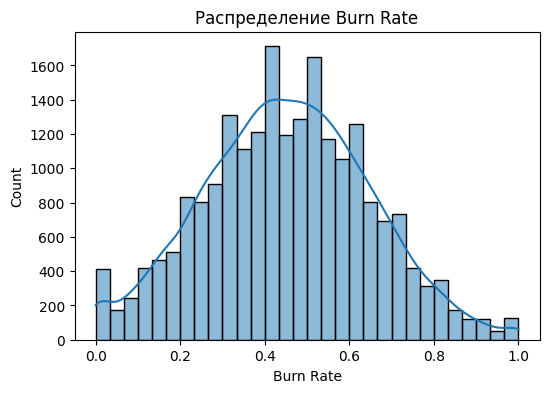

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Burn Rate'], bins=30, kde=True)
plt.title("Распределение Burn Rate")
plt.show()

Распределение нормальное, сильных выбросов нет

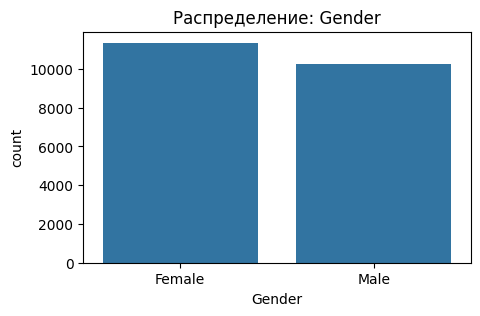

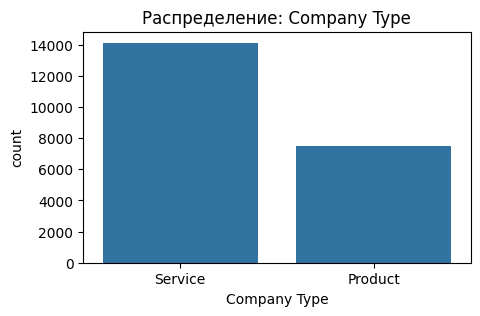

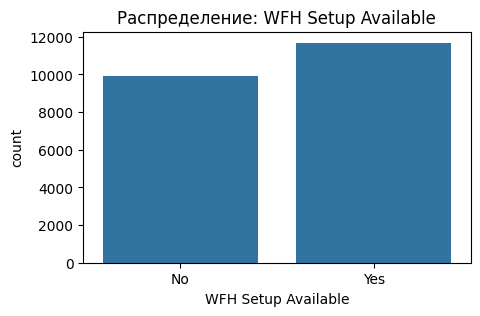

In [ ]:
categorical_cols = ['Gender', 'Company Type', 'WFH Setup Available']

for col in categorical_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.title(f"Распределение: {col}")
    plt.show()

Дисбаланс среди женщин и мужчин есть, но некритичный. Больше сотрудников из сервисных компаний. Чуть больше сотрудников с возможносью работать из дома.

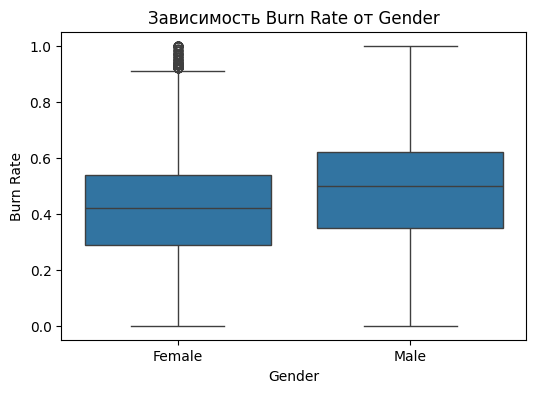

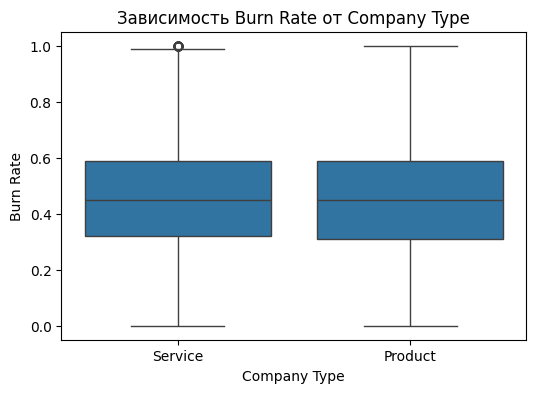

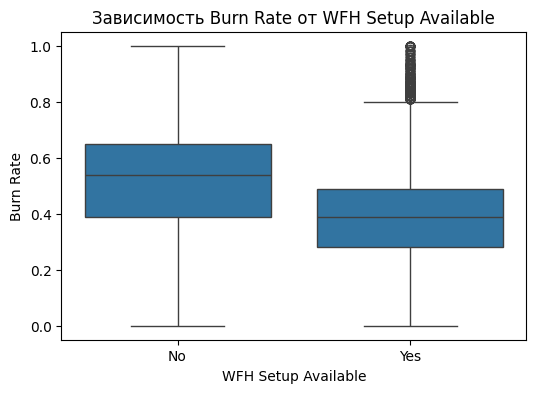

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=col, y='Burn Rate')
    plt.title(f"Зависимость Burn Rate от {col}")
    plt.show()

**Зависимость уровня выгорания от пола:**
Гендер не является определяющим фактором для уровня выгорания в среднем. Женщины демонстрируют большее разнообразие в уровне выгорания. Мужчины чаще имеют экстремально высокие показатели выгорания. Возможно, мужчины реже признают средний уровень выгорания, чаще либо не испытывают его, либо испытывают в крайней степени

**Зависимость уровня выгорания от типа компании:**
Тип компании не является сильным дифференцирующим фактором уровня выгорания

**Зависимость уровня выгорания от возможности удаленной работы:**
Наличие возможности работать из дома связано с более низким уровнем выгорания.


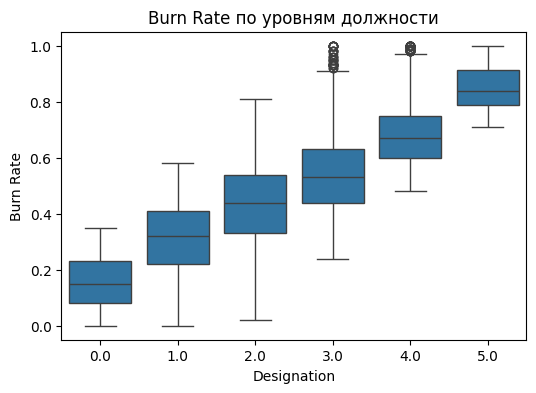

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Designation', y='Burn Rate')
plt.title('Burn Rate по уровням должности')
plt.show()

Чем выше уровень должности, тем выше уровень выгорания

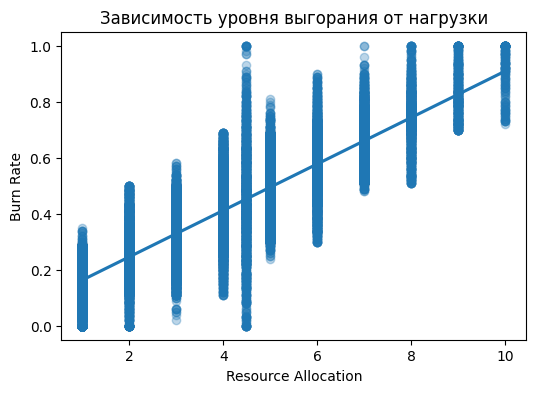

In [ ]:
plt.figure(figsize=(6,4))
sns.regplot(data=df, x='Resource Allocation', y='Burn Rate',scatter_kws={'alpha':0.3})
plt.title('Зависимость уровня выгорания от нагрузки')
plt.show()

Чем выше нагрузка, тем выше уровень выгорания

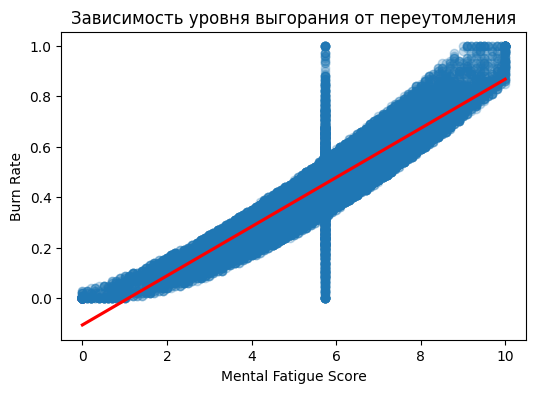

In [ ]:
plt.figure(figsize=(6,4))
sns.regplot(data=df, x='Mental Fatigue Score', y='Burn Rate', scatter_kws={'alpha':0.25}, line_kws={'color':'red'})
plt.title('Зависимость уровня выгорания от переутомления')
plt.show()

Уровень переутомления влияет на уровень выгорания

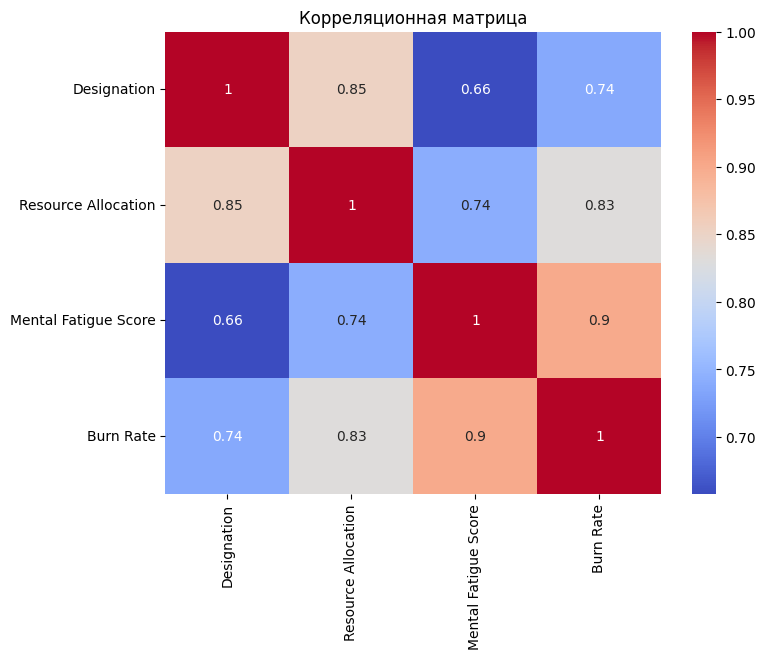

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

Корреляционный анализ показывает, что Burn Rate сильнее всего связан с Mental Fatigue Score. Ментальная усталость возможно измеряется одновременно с уровнем выгорания или явялется следствием выгорания.

Можно удалить столбик Employee ID, поскольку эта информация никак не влияет на уровень выгорания

In [ ]:
df = df.drop('Employee ID', axis=1)

In [ ]:
df=df.reset_index(drop=True)
df.head()

,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,2008-09-30,Female,Service,No,2.0,3.000000,3.8,0.16
1,2008-11-30,Male,Service,Yes,1.0,2.000000,5.0,0.36
2,2008-03-10,Female,Product,Yes,2.0,4.483831,5.8,0.49
3,2008-11-03,Male,Service,Yes,1.0,1.000000,2.6,0.20
4,2008-07-24,Female,Service,No,3.0,7.000000,6.9,0.52


Машинное обучение

**CatBoostRegressor**

In [ ]:
# Преобразуем дату в формат datetime
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])
# Создадим новый признак "Days Employed" (Стаж в днях). Считаем от самой последней даты в датасете
max_date = df['Date of Joining'].max()
df['Days_Employed'] = (max_date - df['Date of Joining']).dt.days
# Удаляем исходную колонку с датой, она больше не нужна
df = df.drop('Date of Joining', axis=1)

In [ ]:
X = df.drop('Burn Rate', axis=1)
y = df['Burn Rate']

In [ ]:
cat_features = ['Gender', 'Company Type', 'WFH Setup Available']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = CatBoostRegressor(iterations=500,learning_rate=0.1,depth=6,loss_function='RMSE',verbose=0)

In [ ]:
#model.fit(X_train, y_train, cat_features=cat_features)

0:	learn: 0.1829234	total: 51.8ms	remaining: 25.8s
100:	learn: 0.0594541	total: 332ms	remaining: 1.31s
200:	learn: 0.0580231	total: 605ms	remaining: 899ms
300:	learn: 0.0571063	total: 877ms	remaining: 580ms
400:	learn: 0.0563993	total: 1.25s	remaining: 308ms
499:	learn: 0.0557911	total: 2.09s	remaining: 0us


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.1, loss_function='RMSE', verbose=100)

In [ ]:
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    verbose=0
)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.1, loss_function='RMSE', verbose=0)

In [ ]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nТочность модели (R2): {r2:.4f}")
print(f"Средняя ошибка (MAE): {mae:.4f}")


Точность модели (R2): 0.9088
Средняя ошибка (MAE): 0.0466


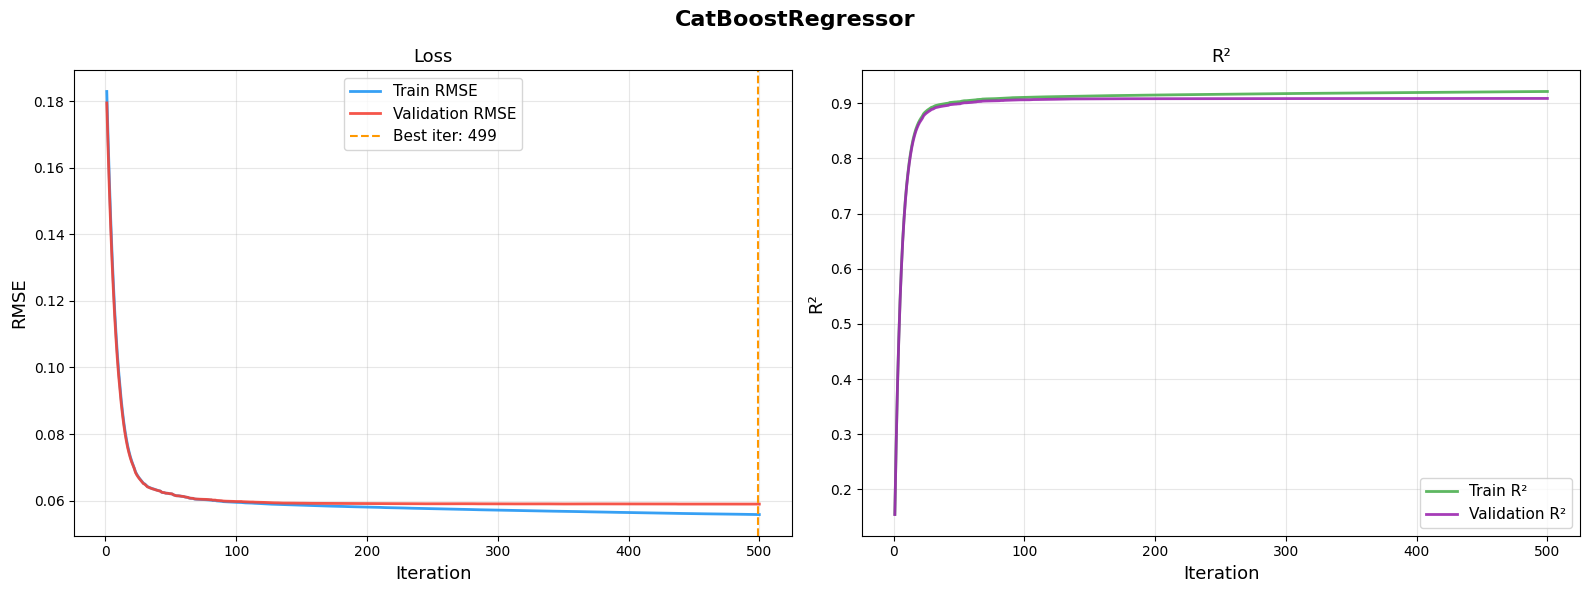

Лучшая итерация (мин. Validation RMSE): 499
Final Train RMSE:      0.0558
Final Validation RMSE: 0.0589
Final Validation R²:   0.9088


In [ ]:
evals_result = model.get_evals_result()

train_rmse = np.array(evals_result['learn']['RMSE'])
val_rmse   = np.array(evals_result['validation']['RMSE'])
iterations = np.arange(1, len(train_rmse) + 1)

# R² ≈ 1 - (RMSE² / Var(y))  — быстрый аналог без перебора моделей
var_train = np.var(y_train.values)
var_test  = np.var(y_test.values)
train_r2  = 1 - (train_rmse ** 2) / var_train
val_r2    = 1 - (val_rmse   ** 2) / var_test

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CatBoostRegressor', fontsize=16, fontweight='bold')

# --- Plot 1: RMSE Loss ---
ax1 = axes[0]
ax1.plot(iterations, train_rmse, color='#2196F3', linewidth=2, label='Train RMSE', alpha=0.9)
ax1.plot(iterations, val_rmse,   color='#F44336', linewidth=2, label='Validation RMSE', alpha=0.9)
best_it = int(np.argmin(val_rmse)) + 1
ax1.axvline(x=best_it, color='#FF9800', linestyle='--', linewidth=1.5, label=f'Best iter: {best_it}')
ax1.set_xlabel('Iteration', fontsize=13)
ax1.set_ylabel('RMSE', fontsize=13)
ax1.set_title('Loss', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Plot 2: R² Score ---
ax2 = axes[1]
ax2.plot(iterations, train_r2, color='#4CAF50', linewidth=2, label='Train R²', alpha=0.9)
ax2.plot(iterations, val_r2,   color='#9C27B0', linewidth=2, label='Validation R²', alpha=0.9)
ax2.set_xlabel('Iteration', fontsize=13)
ax2.set_ylabel('R²', fontsize=13)
ax2.set_title('R²', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('catboost_training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Лучшая итерация (мин. Validation RMSE): {best_it}")
print(f"Final Train RMSE:      {train_rmse[-1]:.4f}")
print(f"Final Validation RMSE: {val_rmse[-1]:.4f}")
print(f"Final Validation R²:   {val_r2[-1]:.4f}")

In [ ]:
df['Gender'] = df['Gender'].replace({'Female': 0, 'Male': 1})
df['Company Type'] = df['Company Type'].replace({'Product': 0, 'Service': 1})
df['WFH Setup Available'] = df['WFH Setup Available'].replace({'No': 0, 'Yes': 1})

/tmp/ipython-input-37499070.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Female': 0, 'Male': 1})
/tmp/ipython-input-37499070.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Company Type'] = df['Company Type'].replace({'Product': 0, 'Service': 1})
/tmp/ipython-input-37499070.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the f

In [ ]:
X = df.drop('Burn Rate', axis=1)
y = df['Burn Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Linear Regression**

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
print(f"Точность модели (R2 Score): {r2_score(y_test, lr_pred):.4f}")
print(f"Средняя ошибка (MAE): {mean_absolute_error(y_test, lr_pred):.4f}")

Точность модели (R2 Score): 0.8686
Средняя ошибка (MAE): 0.0535


**Random Forest**

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
print(f"Точность модели (R2 Score): {r2_score(y_test, rf_pred):.4f}")
print(f"Средняя ошибка (MAE): {mean_absolute_error(y_test, rf_pred):.4f}")

Точность модели (R2 Score): 0.9078
Средняя ошибка (MAE): 0.0466


**Neural Network**

In [ ]:
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

mlp_pred = mlp_model.predict(X_test_scaled)
print(f"Точность модели (R2 Score): {r2_score(y_test, mlp_pred):.4f}")
print(f"Средняя ошибка (MAE): {mean_absolute_error(y_test, mlp_pred):.4f}")

Точность модели (R2 Score): 0.8819
Средняя ошибка (MAE): 0.0516


Наилучшую точность показала CatBoostRegressor

In [ ]:
model.save_model("burnout_model.cbm")